In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import typing
import pandas as pd
import numpy as np
import scipy
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.multitest

import common_data
import common_plots

In [3]:
%config InlineBackend.figure_format = "retina"

In [4]:
common_plots.setup_plotting()

In [5]:
df = common_data.get_sc_categorical_covariates()

# Correlation structure in our labels

Check what are significant relationships in the data as it is. We're interested in:
- died/survived
- pathogen groups
- episode category
- vap onset
- vap cure
- sex
- ecmo
- crrt?
- hd?


In [6]:
COLUMNS = [
    'Binary_outcome',
    'Pathogen_groups',
    'Episode_category',
    'VAP_onset_within_7d',
    'VAP_is_cured_d7',
    'Sex',
    'ECMO_flag',
    'CRRT_flag',
    'Hemodialysis_flag',
    'Immunocompromised_flag',
    'Episode_etiology',
    'Pathogen_bacteria_detected',
    'Pathogen_virus_detected',
    'is_culture_negative_pneumonia'
]

In [7]:
sc_labels = pd.read_csv(common_data.SC_LABELS, index_col=0)

In [8]:
df['is_culture_negative_pneumonia'] = sc_labels.set_index('bal_barcode')['is_culture_negative_pneumonia']
df.is_culture_negative_pneumonia = df.is_culture_negative_pneumonia.replace({False: 'No', True: 'Yes'}).fillna('NA')

In [9]:
def test_enrichment(
        groups: pd.Series,
        clusters: pd.Series,
        na_values: typing.Dict[str, list]
) -> pd.DataFrame:
    group_values = groups.dropna().unique().tolist()
    cluster_values = clusters.dropna().unique().tolist()
    if groups.name in na_values:
        group_values = list(set(group_values) - set(na_values[groups.name]))
    if clusters.name in na_values:
        cluster_values = list(set(cluster_values) - set(na_values[clusters.name]))
    group_names = groups.name + ': ' + pd.Series(group_values).astype(str)
    cluster_names = clusters.name + ': ' + pd.Series(cluster_values).astype(str)
    idx = groups.isin(group_values) & clusters.isin(cluster_values)
    result = pd.DataFrame(np.nan, index=list(group_names), columns=list(cluster_names))
    if groups.name == 'Pathogen_groups' and clusters.name in ('Episode_etiology', 'Pathogen_bacteria_detected', 'Pathogen_virus_detected', 'is_culture_negative_pneumonia'):
        return result
    if groups.name == 'Episode_etiology' and clusters.name in ('Pathogen_bacteria_detected', 'Pathogen_virus_detected', 'is_culture_negative_pneumonia'):
        return result
    if groups.name == 'Pathogen_bacteria_detected' and clusters.name in ('Pathogen_virus_detected', 'is_culture_negative_pneumonia'):
        return result
    if groups.name == 'Pathogen_virus_detected' and clusters.name == 'is_culture_negative_pneumonia':
        return result

    for group in group_values:
        for cluster in cluster_values:
            if groups.name == 'Pathogen_groups' and group == 'NPC' and clusters.name == 'Episode_category' and cluster == 'NPC':
                continue
            if groups.name == 'Episode_category' and group == 'VAP' and clusters.name == 'VAP_is_cured_d7':
                continue

            M = idx.sum()
            n = (idx & groups.eq(group)).sum()
            N = (idx & clusters.eq(cluster)).sum()
            k = (groups.eq(group) & clusters.eq(cluster)).sum()
            # print(group, cluster, M, n, N, k)
            if k == 0:
                pval = np.nan
            else:
                pval = 1 - scipy.stats.hypergeom.cdf(k=k - 1, M=M, n=n, N=N)
            group_name = groups.name + ': ' + group
            cluster_name = clusters.name + ': ' + cluster
            result.loc[group_name, cluster_name] = pval
    return result

In [10]:
na_values = {
    col: ['NA']
    for col
    in df.columns
}

In [11]:
for col, val in common_data.na_values.items():
    if col in na_values:
        na_values[col].append(val)

In [12]:
result = pd.DataFrame()
for i in range(len(COLUMNS)):
    for j in range(len(COLUMNS)):
        if j <= i:
            continue
        if COLUMNS[i] == 'VAP_onset_within_7d' or COLUMNS[j] == 'VAP_onset_within_7d':
            # we skip VAP onset for scRNA-seq, too few samples
            continue
        piece = test_enrichment(
            df.loc[:, COLUMNS[i]],
            df.loc[:, COLUMNS[j]],
            na_values=na_values
        )
        for idx in piece.index:
            result.loc[idx, piece.columns.tolist()] = piece.loc[idx, :].copy()

In [13]:
# Create a mask of non-NaN values
mask = ~result.isna()

# Extract non-NaN p-values for FDR correction
p_values = result.values[mask]

# Apply FDR correction to non-NaN values
rejected, p_corrected = statsmodels.stats.multitest.fdrcorrection(p_values)

# Create a new dataframe with the same structure as result
fdr_result = pd.DataFrame(np.empty(result.shape), index=result.index, columns=result.columns)
fdr_result.values[:] = np.nan  # Initialize with NaN values

# Fill in the FDR-corrected p-values in the corresponding positions
fdr_result.values[mask] = p_corrected

# This creates fdr_result with adjusted p-values, preserving NaN values from the original result dataframe

<Axes: >

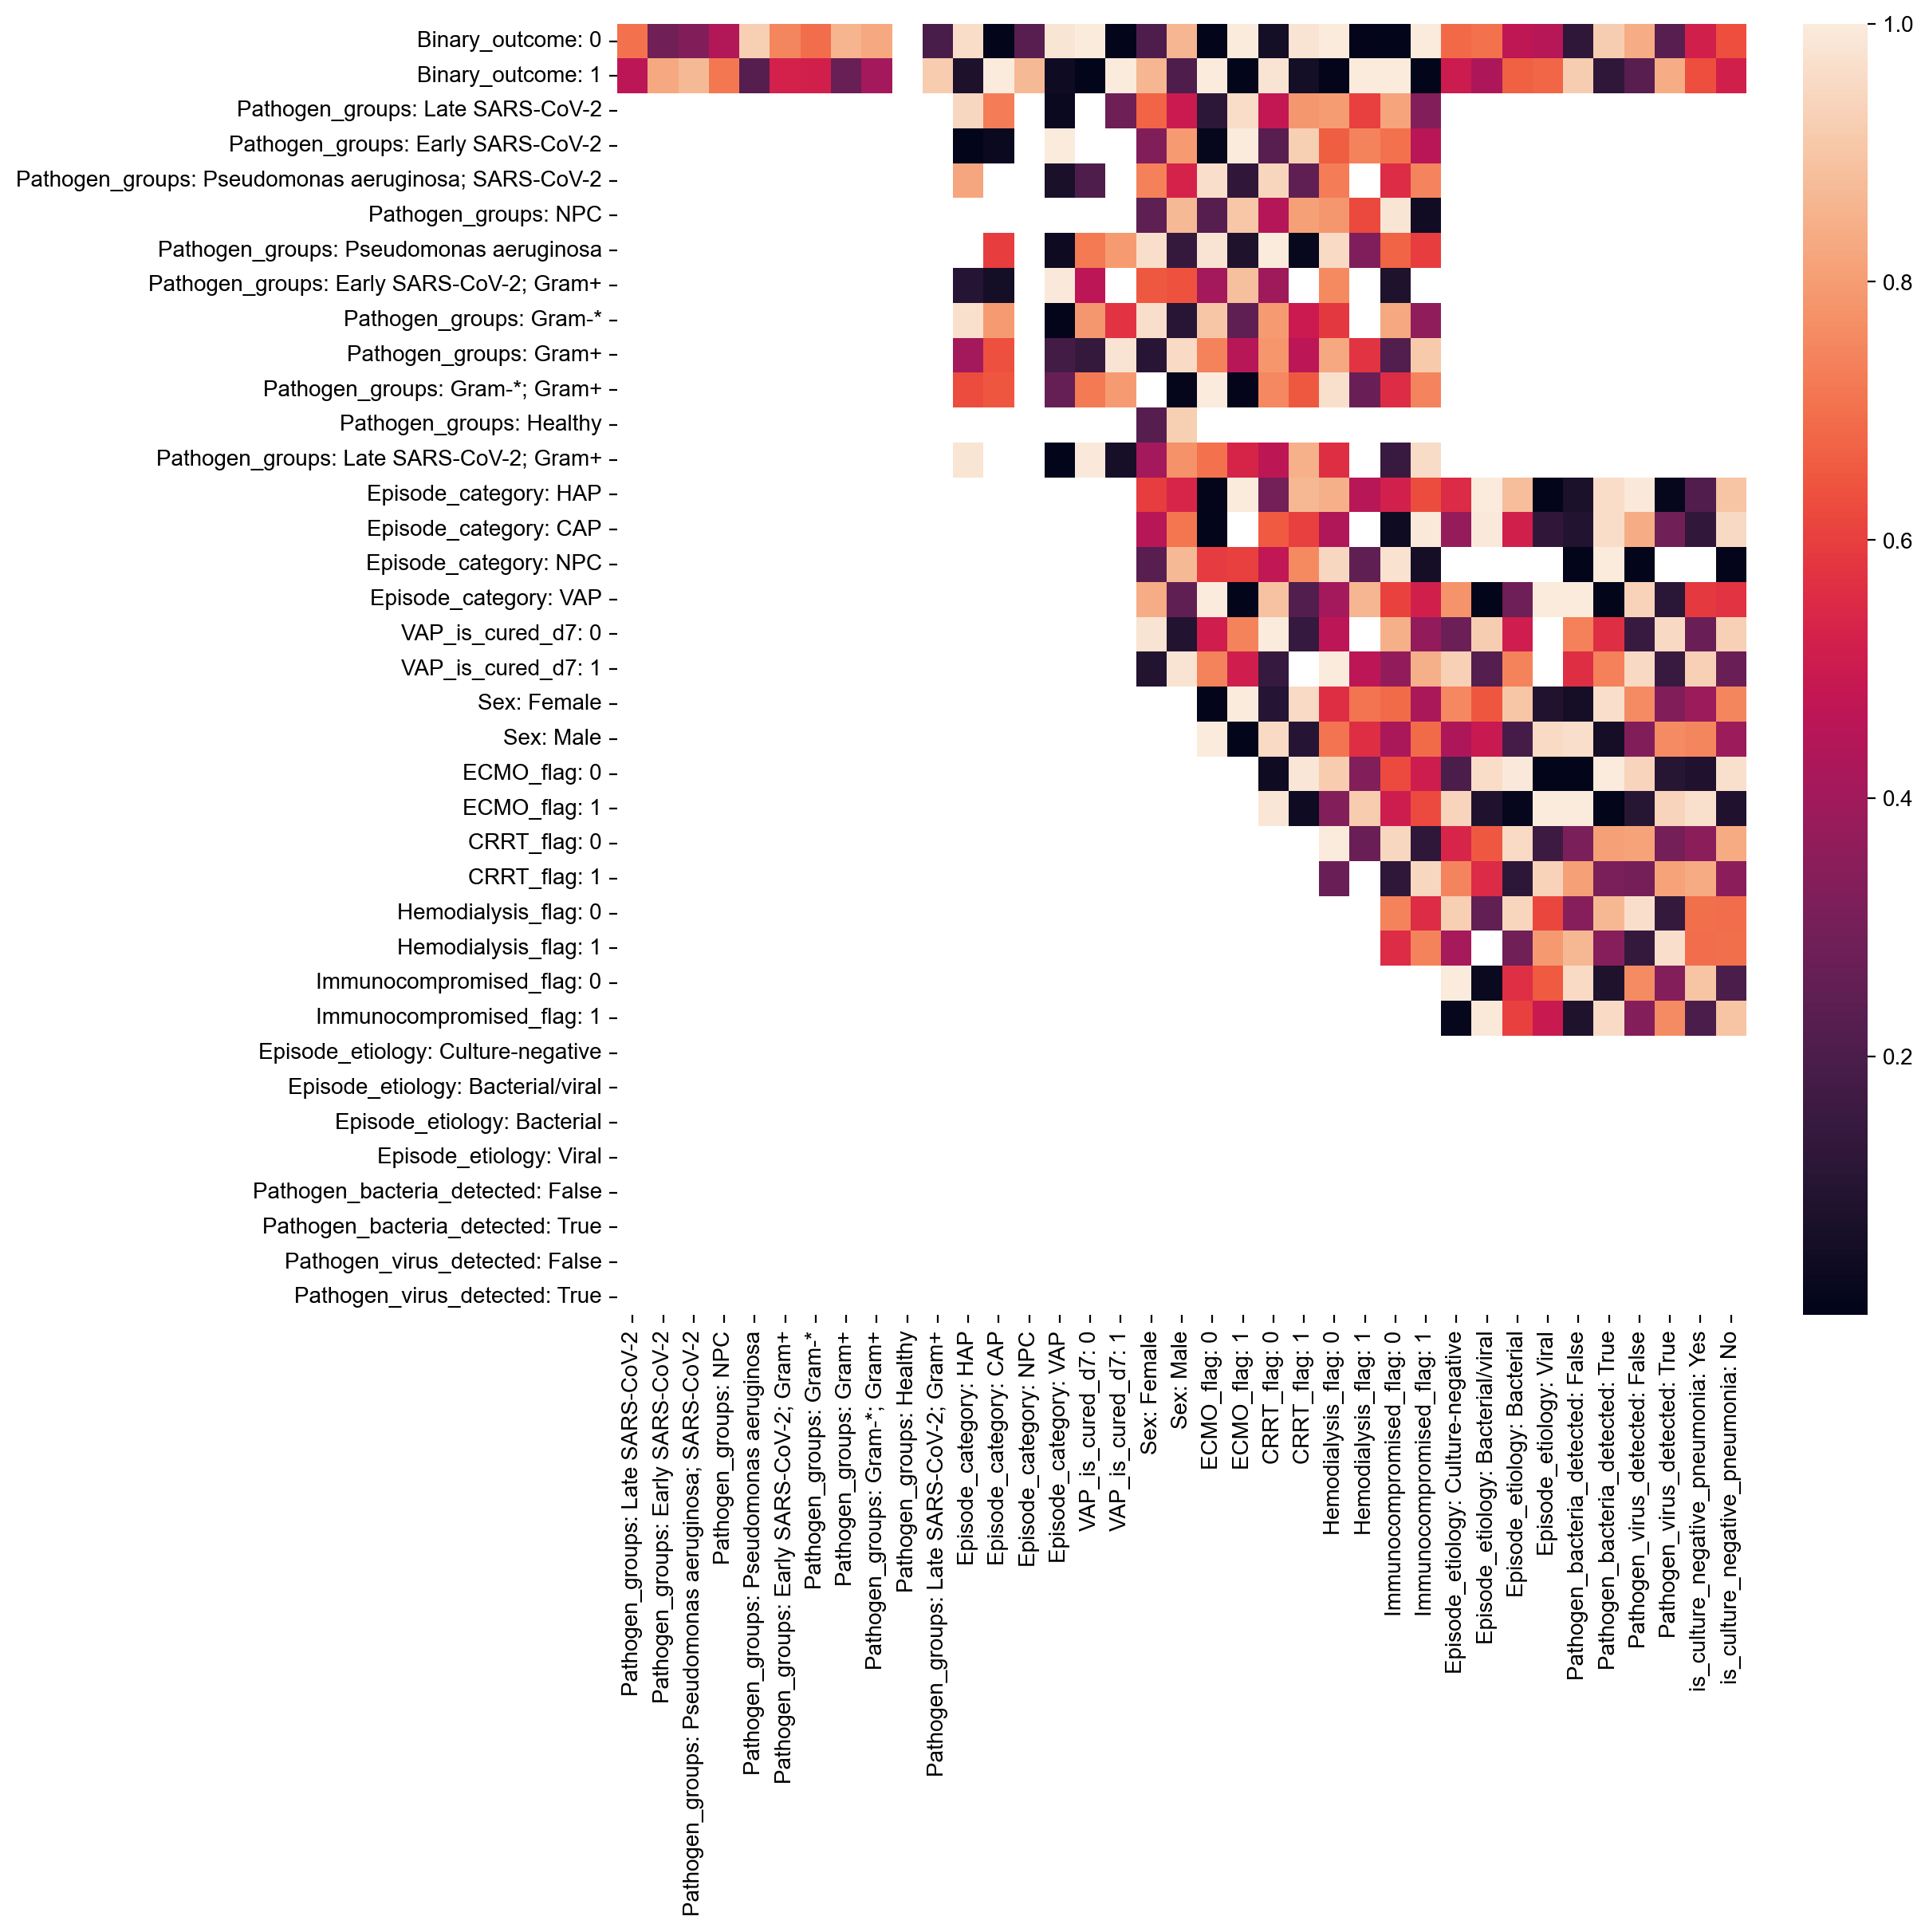

In [14]:
fig, ax = plt.subplots(figsize=(12, 12), constrained_layout=True)
sns.heatmap(
    result.fillna(0),
    mask=result.isna(),
    yticklabels=result.index,
    xticklabels=result.columns,
    ax=ax
)

In [15]:
CAT_DISPLAY = {
    'Binary_outcome': 'Mortality',
    'VAP_is_cured_d7': 'VAP cure in 7 days',
    'VAP_onset_within_7d': 'VAP onset within 7 days',
    'is_culture_negative_pneumonia': 'Pathogen-negative pneumonia',
    'Episode_etiology': 'Adjudicated pathogen'
}
PATH_DISPLAY = {
    'Gram-*': 'Other Gram–',
    'Gram-*; Gram+': 'Other Gram–; Gram+',
}
VAL_DISPLAY = {
    '1': 'Yes',
    '0': 'No',
    'True': 'Yes',
    'False': 'No',
    'Bacterial/viral': 'Mixed',
    # 'Viral': 'viral',
    # 'Bacterial': 'bacterial',
    'Culture-negative': 'Negative'
}

def display_label(t):
    cat, value = t.split(': ')
    cat = CAT_DISPLAY.get(cat, cat)
    if cat == 'Pathogen_groups':
        return PATH_DISPLAY.get(value, value)
    return cat.replace('_flag', '').replace('_', ' ') + ': ' + VAL_DISPLAY.get(value, value)

0 associations with exact 0 p-value


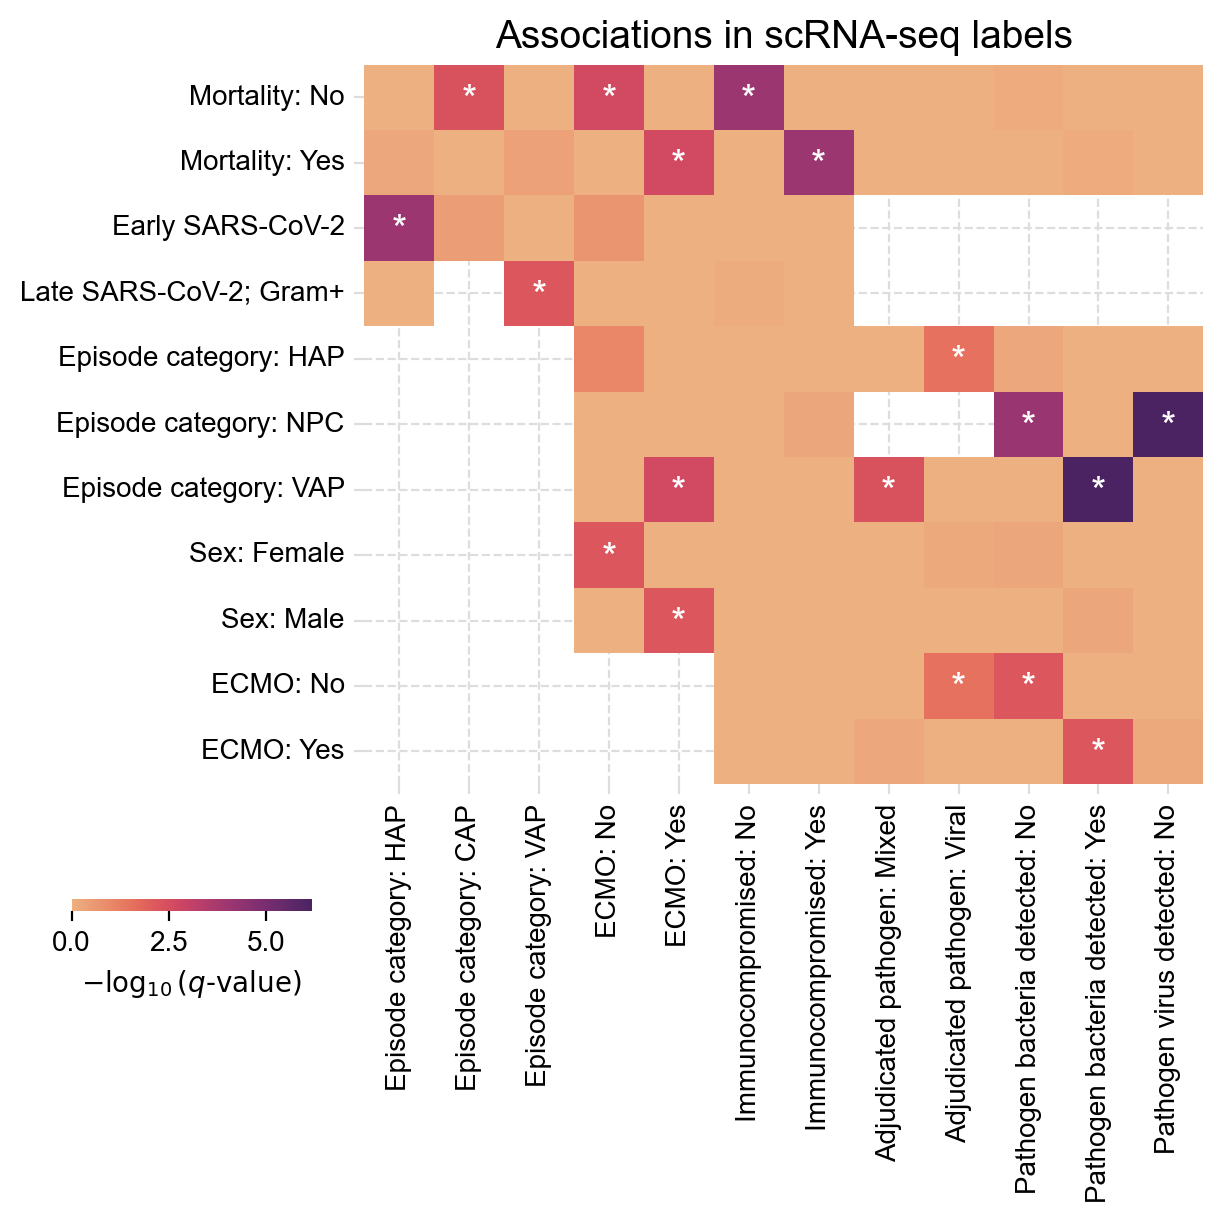

In [16]:
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
cax = fig.add_axes((0.05, 0.25, 0.2, 0.01))
stars = fdr_result.copy()
stars = stars.applymap(lambda x: np.isnan(x) and '' or x < 0.05 and '*' or '')
signif_row_idx = fdr_result.lt(0.05).sum(axis=1).gt(0).values
signif_col_idx = fdr_result.lt(0.05).sum(axis=0).gt(0).values
log10_result = fdr_result.astype(float).to_numpy()
log10_result[:] = -np.log10(log10_result)
log10_result[np.isnan(log10_result)] = 0
inf_idx = ~np.isfinite(log10_result)
print(inf_idx.sum(), 'associations with exact 0 p-value')
log10_result[inf_idx] = log10_result[~inf_idx].max() + 1
sns.heatmap(
    log10_result[signif_row_idx][:, signif_col_idx],
    mask=fdr_result.isna().to_numpy()[signif_row_idx][:, signif_col_idx],
    yticklabels=[display_label(l) for l in result.index[signif_row_idx]],
    xticklabels=[display_label(l) for l in result.columns[signif_col_idx]],
    annot=stars.loc[signif_row_idx].loc[:, signif_col_idx],
    fmt='s',
    ax=ax,
    cmap='flare',
    cbar_ax=cax,
    cbar_kws=dict(
        orientation='horizontal',
        label=r'$-\log_{10}(q\text{-value})$',
        ticks=[0, 2.5, 5, 7.5]
    ),
    annot_kws=dict(
        size=14,
    ),
    zorder=2
)
ax.set_title('Associations in scRNA-seq labels', size=14)
ax.grid(color='#ddd', zorder=5, ls='dashed')
ax.tick_params(color='#ddd')
# cax.set_xticks([0, 2.5, 5, 7.5], labels=['0', '2.5', '5', '7.5'])
trans = mpl.transforms.Affine2D().translate(0, -4)
for t in ax.texts:
    if t.get_text() == '*':
        t.set_transform(t.get_transform() + trans)
fig.savefig('00_figures/06_corr_structure_scrna.pdf')

## Now for EHR

In [17]:
ehr = pd.read_csv(common_data.CLINICAL, index_col=0)

In [18]:
ehr_labels = pd.read_csv(common_data.CLINICAL_LABELS, index_col=0)

In [19]:
ehr_labels = ehr_labels.merge(ehr[[
    'Gender',
    'Episode_category',
    # 'Episode_etiology',
    'ECMO_flag',
    'CRRT_flag',
    'Hemodialysis_flag',
    'Pathogen_bacteria_detected',
    'Pathogen_virus_detected',
    'Episode_duration',
    'Episode_is_cured',
    'Virus_cleared_on'
]], left_index=True, right_index=True)

In [20]:
ehr_labels['Virus_detected'] = ehr_labels.Pathogen_virus_detected.copy()
ehr_labels['Bacteria_detected'] = ehr_labels.Pathogen_bacteria_detected.copy()

In [21]:
idx = ehr_labels.Episode_duration.notna() & ehr_labels.Episode_is_cured.eq('Cured')
for i, row in ehr_labels.loc[idx].iterrows():
    try:
        target_idx = ehr_labels.index[int(ehr_labels.index.get_loc(i) + row.Episode_duration)]
    except:
        continue
    target_row = ehr_labels.loc[target_idx]
    if (row.patient == target_row.patient
            and row.ICU_stay == target_row.ICU_stay):
        if np.isnan(target_row.Virus_detected):
            ehr_labels.loc[target_idx, 'Virus_detected'] = False
        if np.isnan(target_row.Bacteria_detected):
            ehr_labels.loc[target_idx, 'Bacteria_detected'] = False

In [22]:
def ffill_detected_flags(patient_stay_df):
    result = []
    prev_vir = np.nan
    prev_bac = np.nan
    virus_cleared = None
    for _, row in patient_stay_df.iterrows():
        if not pd.isnull(row.Virus_cleared_on):
            virus_cleared = row.Virus_cleared_on
        # Clear viruses if virus_cleared
        if virus_cleared == row.ICU_day:
            prev_vir = False
        # Current BAL has priority
        if not pd.isnull(row.Virus_detected):
            prev_vir = row.Virus_detected
        if not pd.isnull(row.Bacteria_detected):
            prev_bac = row.Bacteria_detected
        result.append([prev_vir, prev_bac])
    return pd.DataFrame(result, index=patient_stay_df.index, columns=['Virus_detected', 'Bacteria_detected'])
# here groupby resorts rows, so we cannot just assign with `.values`
# we need to match by index
ffilled_pathogens = ehr_labels.groupby(['patient', 'ICU_stay'], group_keys=False).apply(ffill_detected_flags)
ehr_labels[['Virus_detected', 'Bacteria_detected']] = ffilled_pathogens

In [23]:
ehr_labels.Virus_detected.value_counts(dropna=False)

False    9292
True     3961
NaN      2034
Name: Virus_detected, dtype: int64

In [24]:
ehr_labels.Pathogen_virus_detected.value_counts(dropna=False)

NaN      13564
False     1180
True       543
Name: Pathogen_virus_detected, dtype: int64

In [25]:
ehr_labels.drop(columns=['Pathogen_bacteria_detected', 'Pathogen_virus_detected'], inplace=True)
ehr_labels = ehr_labels.rename(columns={
    'Virus_detected': 'Pathogen_virus_detected',
    'Bacteria_detected': 'Pathogen_bacteria_detected',
})

In [26]:
ehr_labels = ehr_labels.rename(columns=common_data.renames).rename(columns={'Gender': 'Sex'})

In [27]:
for col in ehr_labels.columns:
    na_value = common_data.na_values.get(col, 'NA')
    na_count = ehr_labels[col].isna().sum() + ehr_labels[col].eq(na_value).sum()
    # stupid pandas doesn't work here without `tolist` on bool data
    not_na_values = pd.Series(ehr_labels[col][ehr_labels[col].notna()].unique().tolist())
    if pd.api.types.is_bool_dtype(not_na_values):
        idx = ehr_labels[col].isna()
        ehr_labels[col] = ehr_labels[col].fillna(False).astype(str)
        ehr_labels.loc[idx, col] = na_value
    # numbers are always integers here
    elif pd.api.types.is_numeric_dtype(not_na_values):
        idx = ehr_labels[col].isna()
        ehr_labels[col] = ehr_labels[col].fillna(0).astype(int).astype(str)
        ehr_labels.loc[idx, col] = na_value
    elif pd.api.types.is_string_dtype(not_na_values):
        ehr_labels[col] = ehr_labels[col].fillna(na_value)
    categories = ehr_labels[col].unique().tolist()
    if na_value in categories:
        categories.remove(na_value)
    if na_count > 0:
        categories.append(na_value)
    ehr_labels[col] = pd.Categorical(
        ehr_labels[col],
        categories=categories
    )

In [28]:
result = pd.DataFrame()
for i in range(len(COLUMNS)):
    for j in range(len(COLUMNS)):
        if j <= i:
            continue
        piece = test_enrichment(
            ehr_labels.loc[:, COLUMNS[i]],
            ehr_labels.loc[:, COLUMNS[j]],
            na_values=na_values
        )
        for idx in piece.index:
            result.loc[idx, piece.columns.tolist()] = piece.loc[idx, :].copy()

In [29]:
# Create a mask of non-NaN values
mask = ~result.isna()

# Extract non-NaN p-values for FDR correction
p_values = result.values[mask]

# Apply FDR correction to non-NaN values
rejected, p_corrected = statsmodels.stats.multitest.fdrcorrection(p_values)

# Create a new dataframe with the same structure as result
fdr_result = pd.DataFrame(np.empty(result.shape), index=result.index, columns=result.columns)
fdr_result.values[:] = np.nan  # Initialize with NaN values

# Fill in the FDR-corrected p-values in the corresponding positions
fdr_result.values[mask] = p_corrected

# This creates fdr_result with adjusted p-values, preserving NaN values from the original result dataframe

<Axes: >

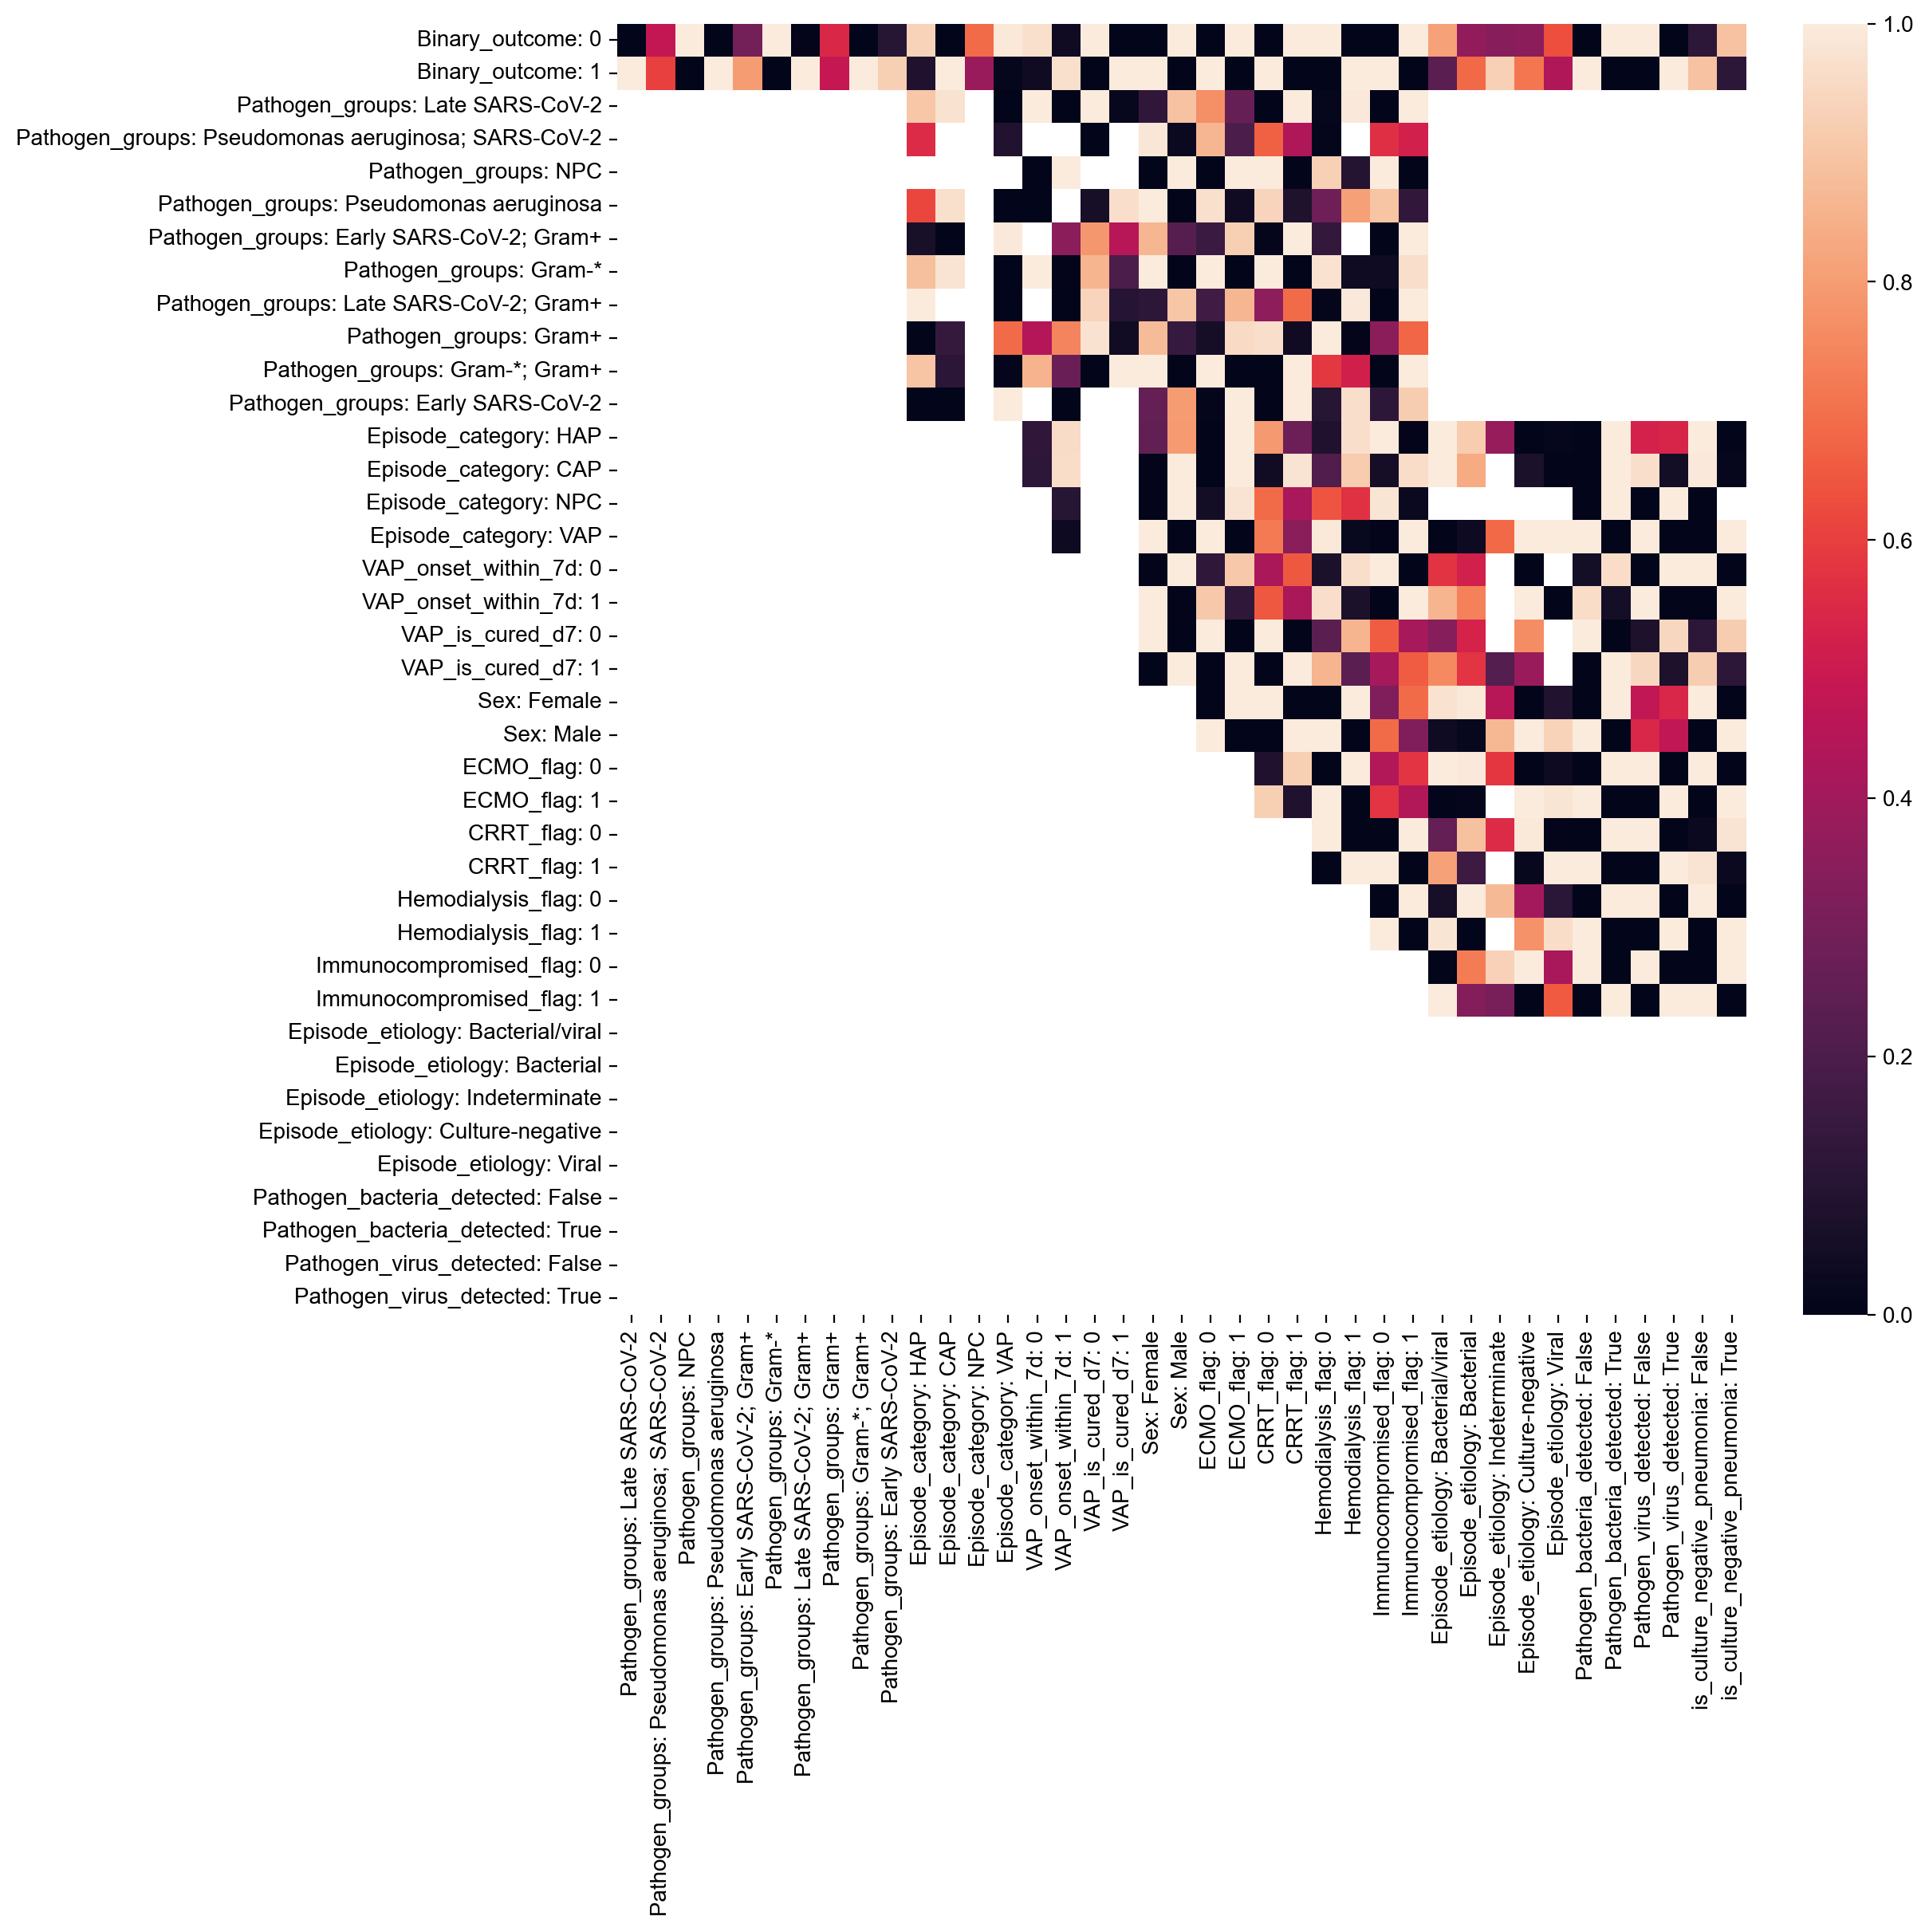

In [30]:
fig, ax = plt.subplots(figsize=(12, 12), constrained_layout=True)
sns.heatmap(
    result.fillna(0),
    mask=result.isna(),
    yticklabels=result.index,
    xticklabels=result.columns,
    ax=ax
)

/tmp/ipykernel_573821/1746462136.py:8: RuntimeWarning: divide by zero encountered in log10
  log10_result[:] = -np.log10(log10_result)


34 associations with exact 0 p-value


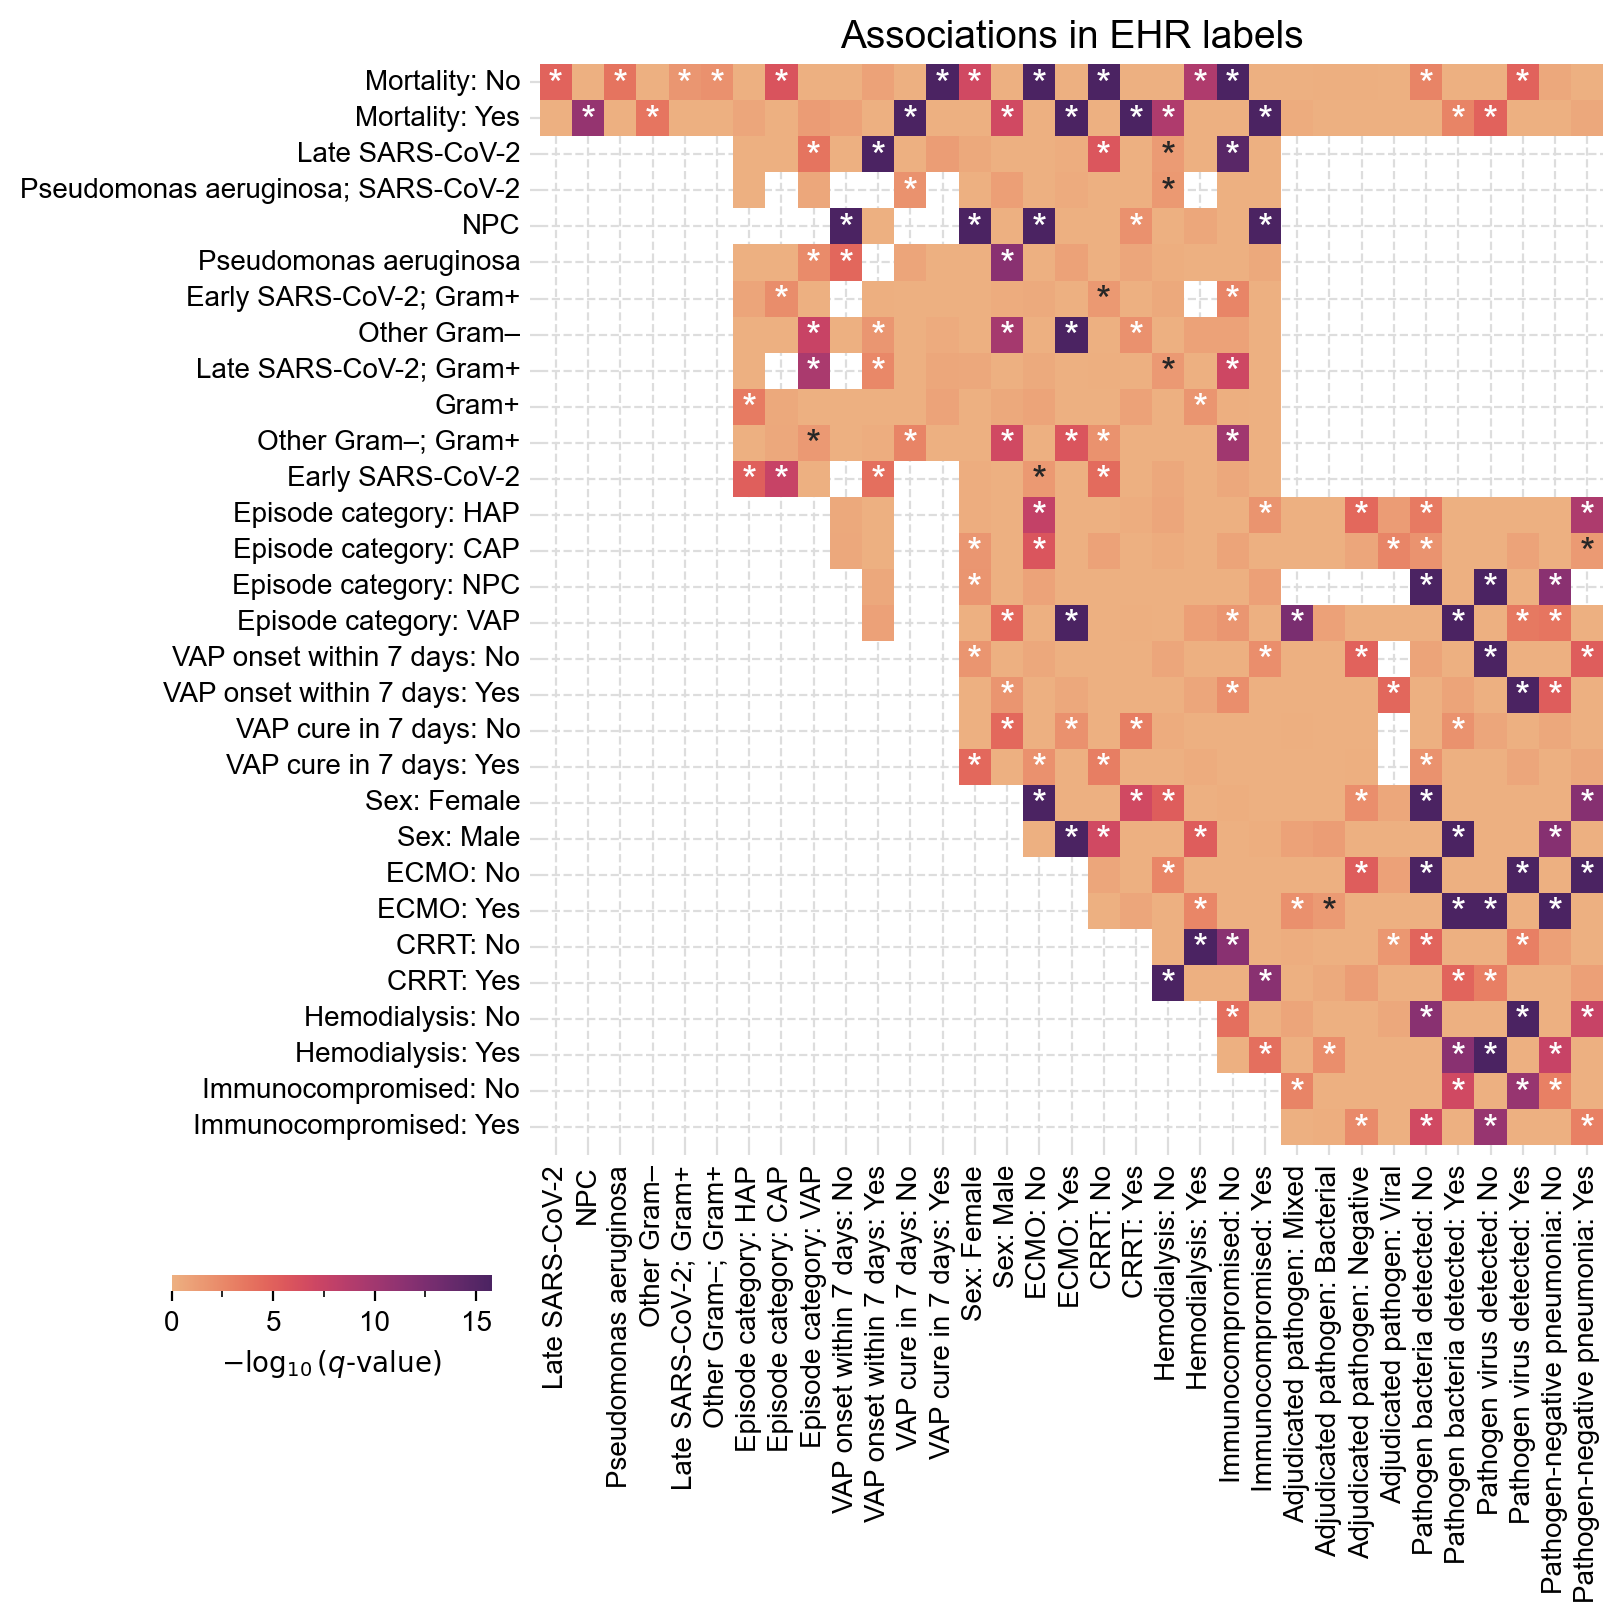

In [31]:
fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
cax = fig.add_axes((0.1, 0.2, 0.2, 0.01))
stars = fdr_result.copy()
stars = stars.applymap(lambda x: np.isnan(x) and '' or x < 0.05 and '*' or '')
signif_row_idx = fdr_result.lt(0.05).sum(axis=1).gt(0).values
signif_col_idx = fdr_result.lt(0.05).sum(axis=0).gt(0).values
log10_result = fdr_result.astype(float).to_numpy()
log10_result[:] = -np.log10(log10_result)
log10_result[np.isnan(log10_result)] = 0
inf_idx = ~np.isfinite(log10_result)
print(inf_idx.sum(), 'associations with exact 0 p-value')
log10_result[inf_idx] = log10_result[~inf_idx].max() + 1
sns.heatmap(
    log10_result[signif_row_idx][:, signif_col_idx],
    mask=fdr_result.isna().to_numpy()[signif_row_idx][:, signif_col_idx],
    yticklabels=[display_label(l) for l in result.index[signif_row_idx]],
    xticklabels=[display_label(l) for l in result.columns[signif_col_idx]],
    annot=stars.loc[signif_row_idx].loc[:, signif_col_idx],
    fmt='s',
    ax=ax,
    cmap='flare',
    cbar_ax=cax,
    cbar_kws=dict(
        orientation='horizontal',
        label=r'$-\log_{10}(q\text{-value})$'
    ),
    annot_kws=dict(
        size=14,
    ),
    zorder=2
)
ax.set_title('Associations in EHR labels', size=14)
ax.grid(color='#ddd', zorder=5, ls='dashed')
ax.tick_params(color='#ddd')
cax.set_xticks([0, 5, 10, 15])
cax.set_xticks([2.5, 7.5, 12.5], minor=True)
trans = mpl.transforms.Affine2D().translate(0, -4)
for t in ax.texts:
    if t.get_text() == '*':
        t.set_transform(t.get_transform() + trans)
fig.savefig('00_figures/06_corr_structure_ehr.pdf')

## Now for Flow

In [28]:
ehr = pd.read_csv(common_data.CLINICAL, index_col=0)

In [29]:
ehr_labels = pd.read_csv(common_data.CLINICAL_LABELS, index_col=0)

In [30]:
ehr_labels = ehr_labels.merge(ehr[[
    'Gender',
    'Episode_category',
    # 'Episode_etiology',
    'ECMO_flag',
    'CRRT_flag',
    'Hemodialysis_flag',
    'Pathogen_bacteria_detected',
    'Pathogen_virus_detected',
]], left_index=True, right_index=True)

In [31]:
flow = pd.read_csv(common_data.FLOW, index_col=0)

In [32]:
flow.shape

(793, 116)

In [33]:
flow.bal_barcode.isin(ehr_labels.bal_barcode).sum()

793

In [34]:
flow_labels = ehr_labels.loc[ehr_labels.bal_barcode.isin(flow.bal_barcode)].copy()

In [35]:
flow_labels = flow_labels.rename(columns=common_data.renames).rename(columns={'Gender': 'Sex'})

In [36]:
for col in flow_labels.columns:
    na_value = common_data.na_values.get(col, 'NA')
    na_count = flow_labels[col].isna().sum() + flow_labels[col].eq(na_value).sum()
    # stupid pandas doesn't work here without `tolist` on bool data
    not_na_values = pd.Series(flow_labels[col][flow_labels[col].notna()].unique().tolist())
    if pd.api.types.is_bool_dtype(not_na_values):
        idx = flow_labels[col].isna()
        flow_labels[col] = flow_labels[col].fillna(False).astype(str)
        flow_labels.loc[idx, col] = na_value
    # numbers are always integers here
    elif pd.api.types.is_numeric_dtype(not_na_values):
        idx = flow_labels[col].isna()
        flow_labels[col] = flow_labels[col].fillna(0).astype(int).astype(str)
        flow_labels.loc[idx, col] = na_value
    elif pd.api.types.is_string_dtype(not_na_values):
        flow_labels[col] = flow_labels[col].fillna(na_value)
    categories = flow_labels[col].unique().tolist()
    if na_value in categories:
        categories.remove(na_value)
    if na_count > 0:
        categories.append(na_value)
    flow_labels[col] = pd.Categorical(
        flow_labels[col],
        categories=categories
    )

In [37]:
result = pd.DataFrame()
for i in range(len(COLUMNS)):
    for j in range(len(COLUMNS)):
        if j <= i:
            continue
        piece = test_enrichment(
            flow_labels.loc[:, COLUMNS[i]],
            flow_labels.loc[:, COLUMNS[j]],
            na_values=na_values
        )
        for idx in piece.index:
            result.loc[idx, piece.columns.tolist()] = piece.loc[idx, :].copy()

In [38]:
# Create a mask of non-NaN values
mask = ~result.isna()

# Extract non-NaN p-values for FDR correction
p_values = result.values[mask]

# Apply FDR correction to non-NaN values
rejected, p_corrected = statsmodels.stats.multitest.fdrcorrection(p_values)

# Create a new dataframe with the same structure as result
fdr_result = pd.DataFrame(np.empty(result.shape), index=result.index, columns=result.columns)
fdr_result.values[:] = np.nan  # Initialize with NaN values

# Fill in the FDR-corrected p-values in the corresponding positions
fdr_result.values[mask] = p_corrected

# This creates fdr_result with adjusted p-values, preserving NaN values from the original result dataframe

<Axes: >

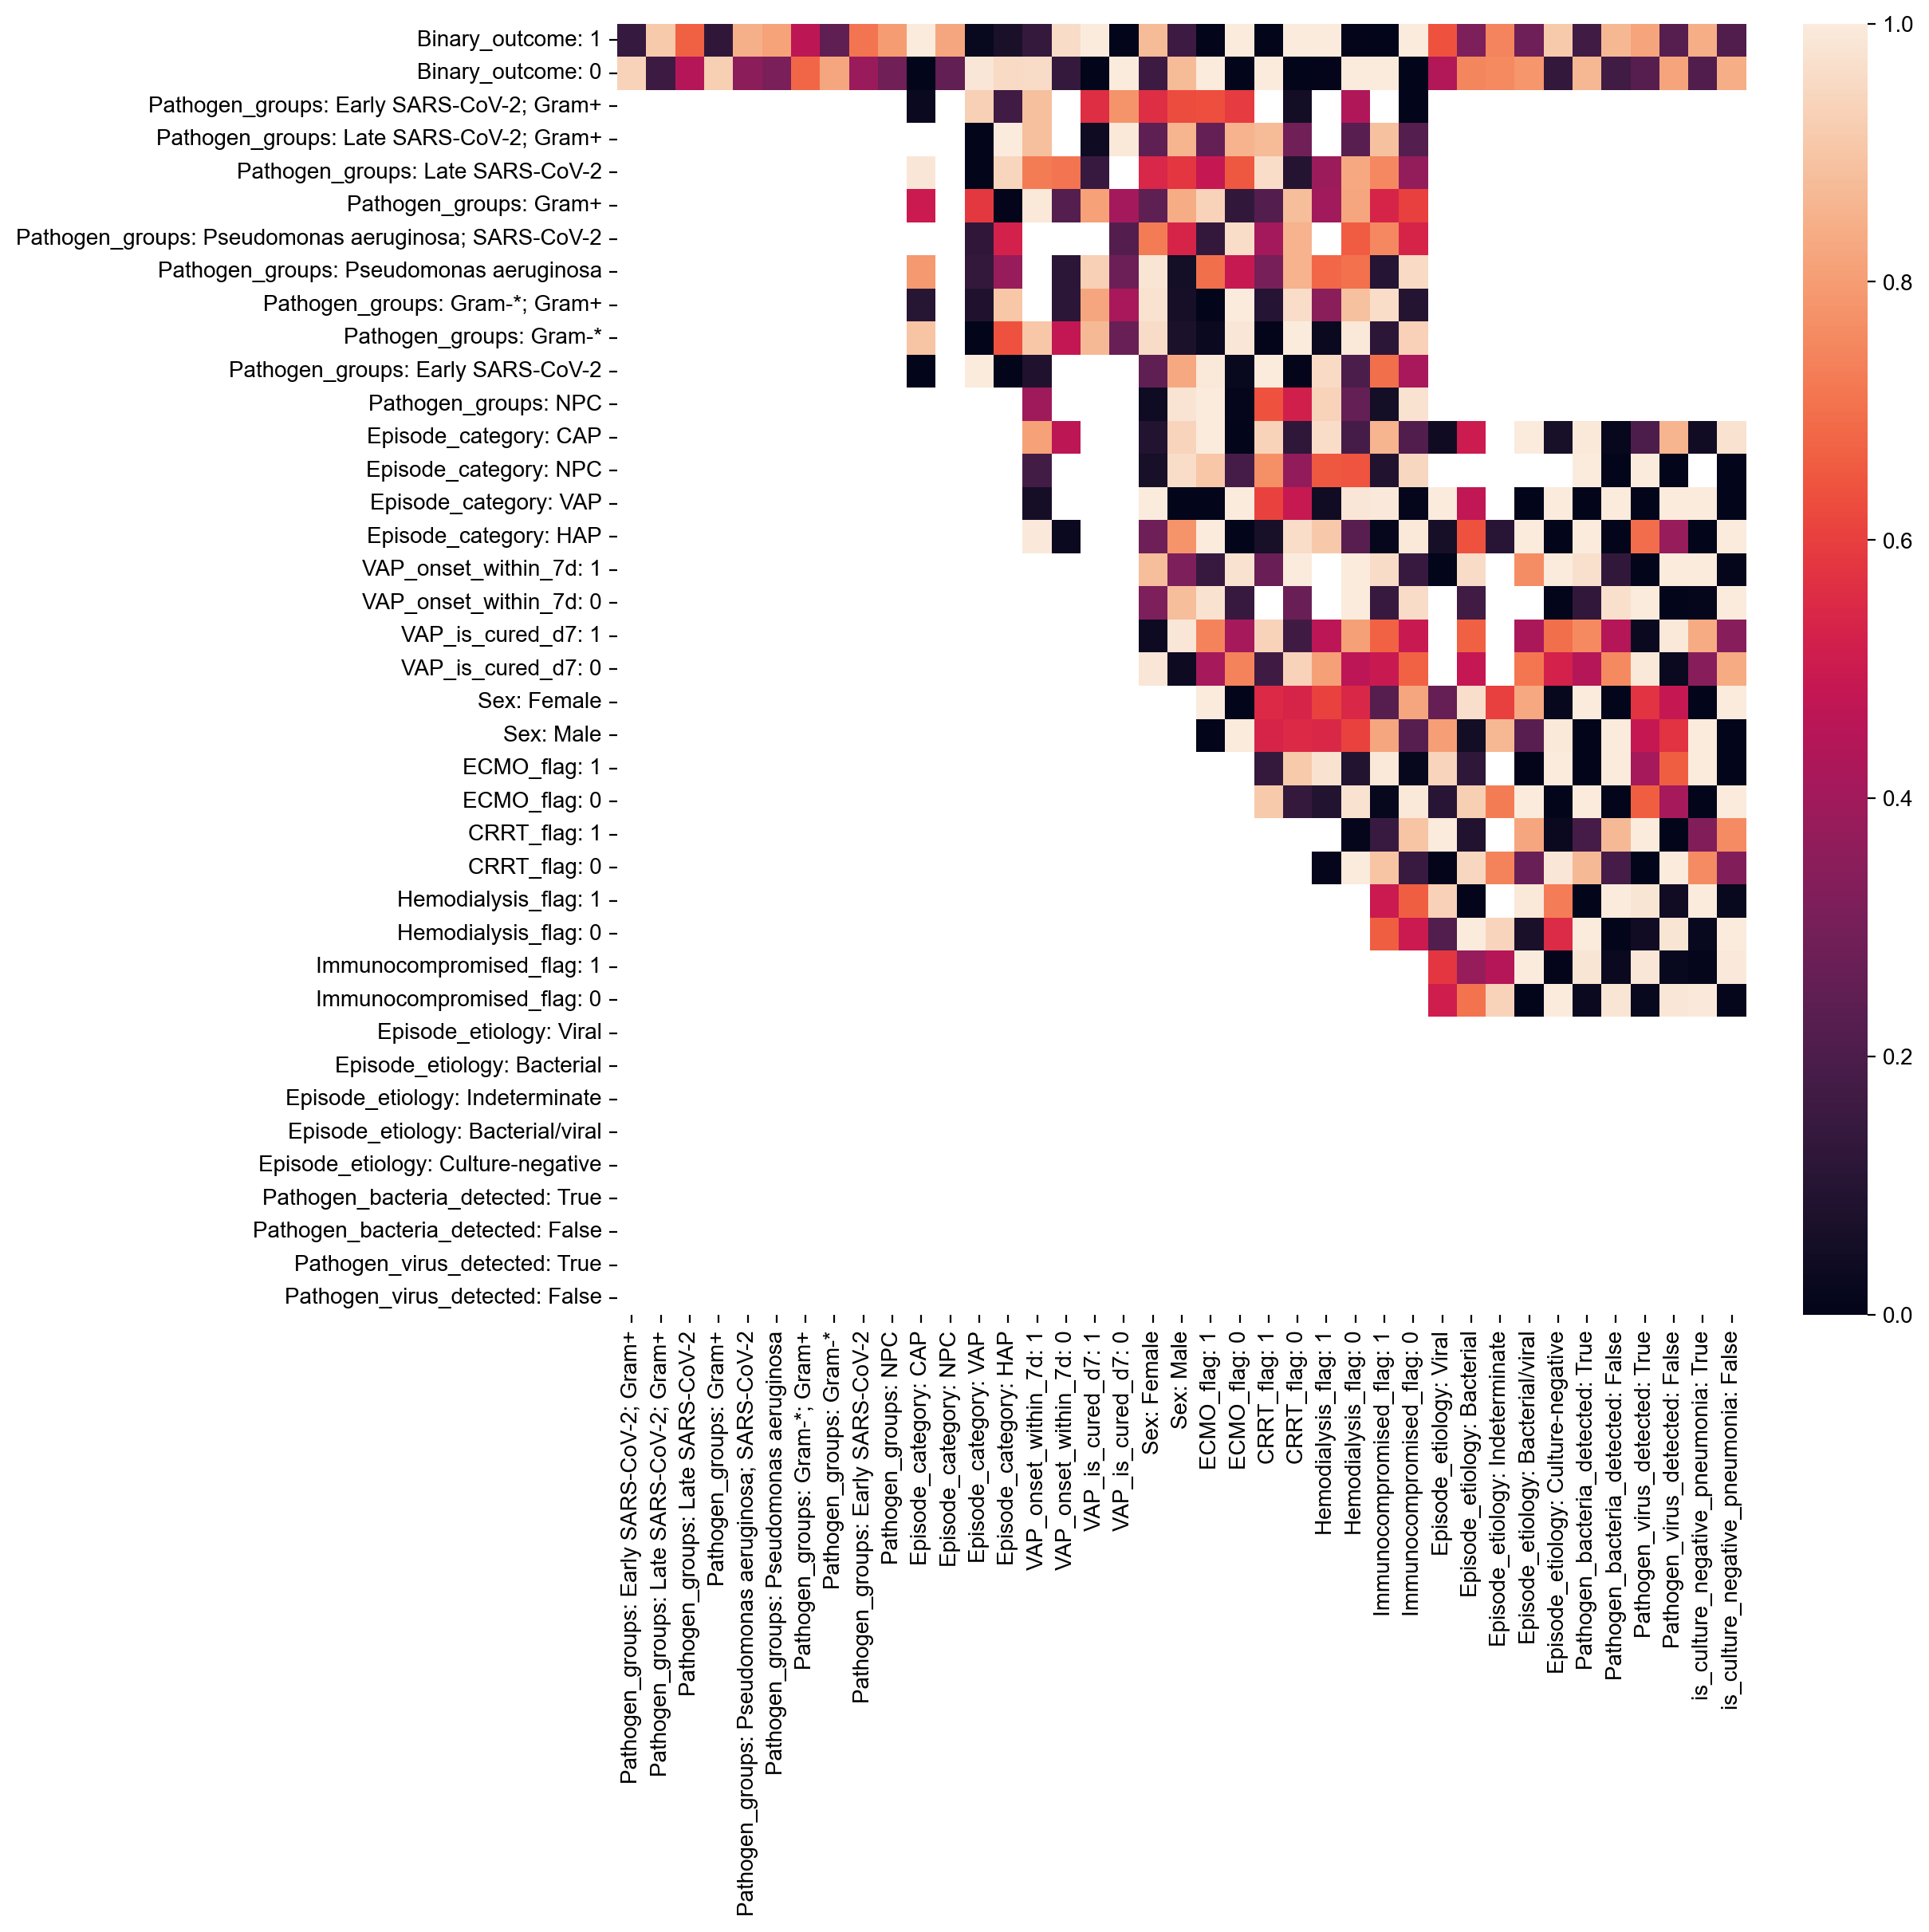

In [39]:
fig, ax = plt.subplots(figsize=(12, 12), constrained_layout=True)
sns.heatmap(
    result.fillna(0),
    mask=result.isna(),
    yticklabels=result.index,
    xticklabels=result.columns,
    ax=ax
)

/tmp/ipykernel_1383204/1918498984.py:8: RuntimeWarning: divide by zero encountered in log10
  log10_result[:] = -np.log10(log10_result)


1 associations with exact 0 p-value


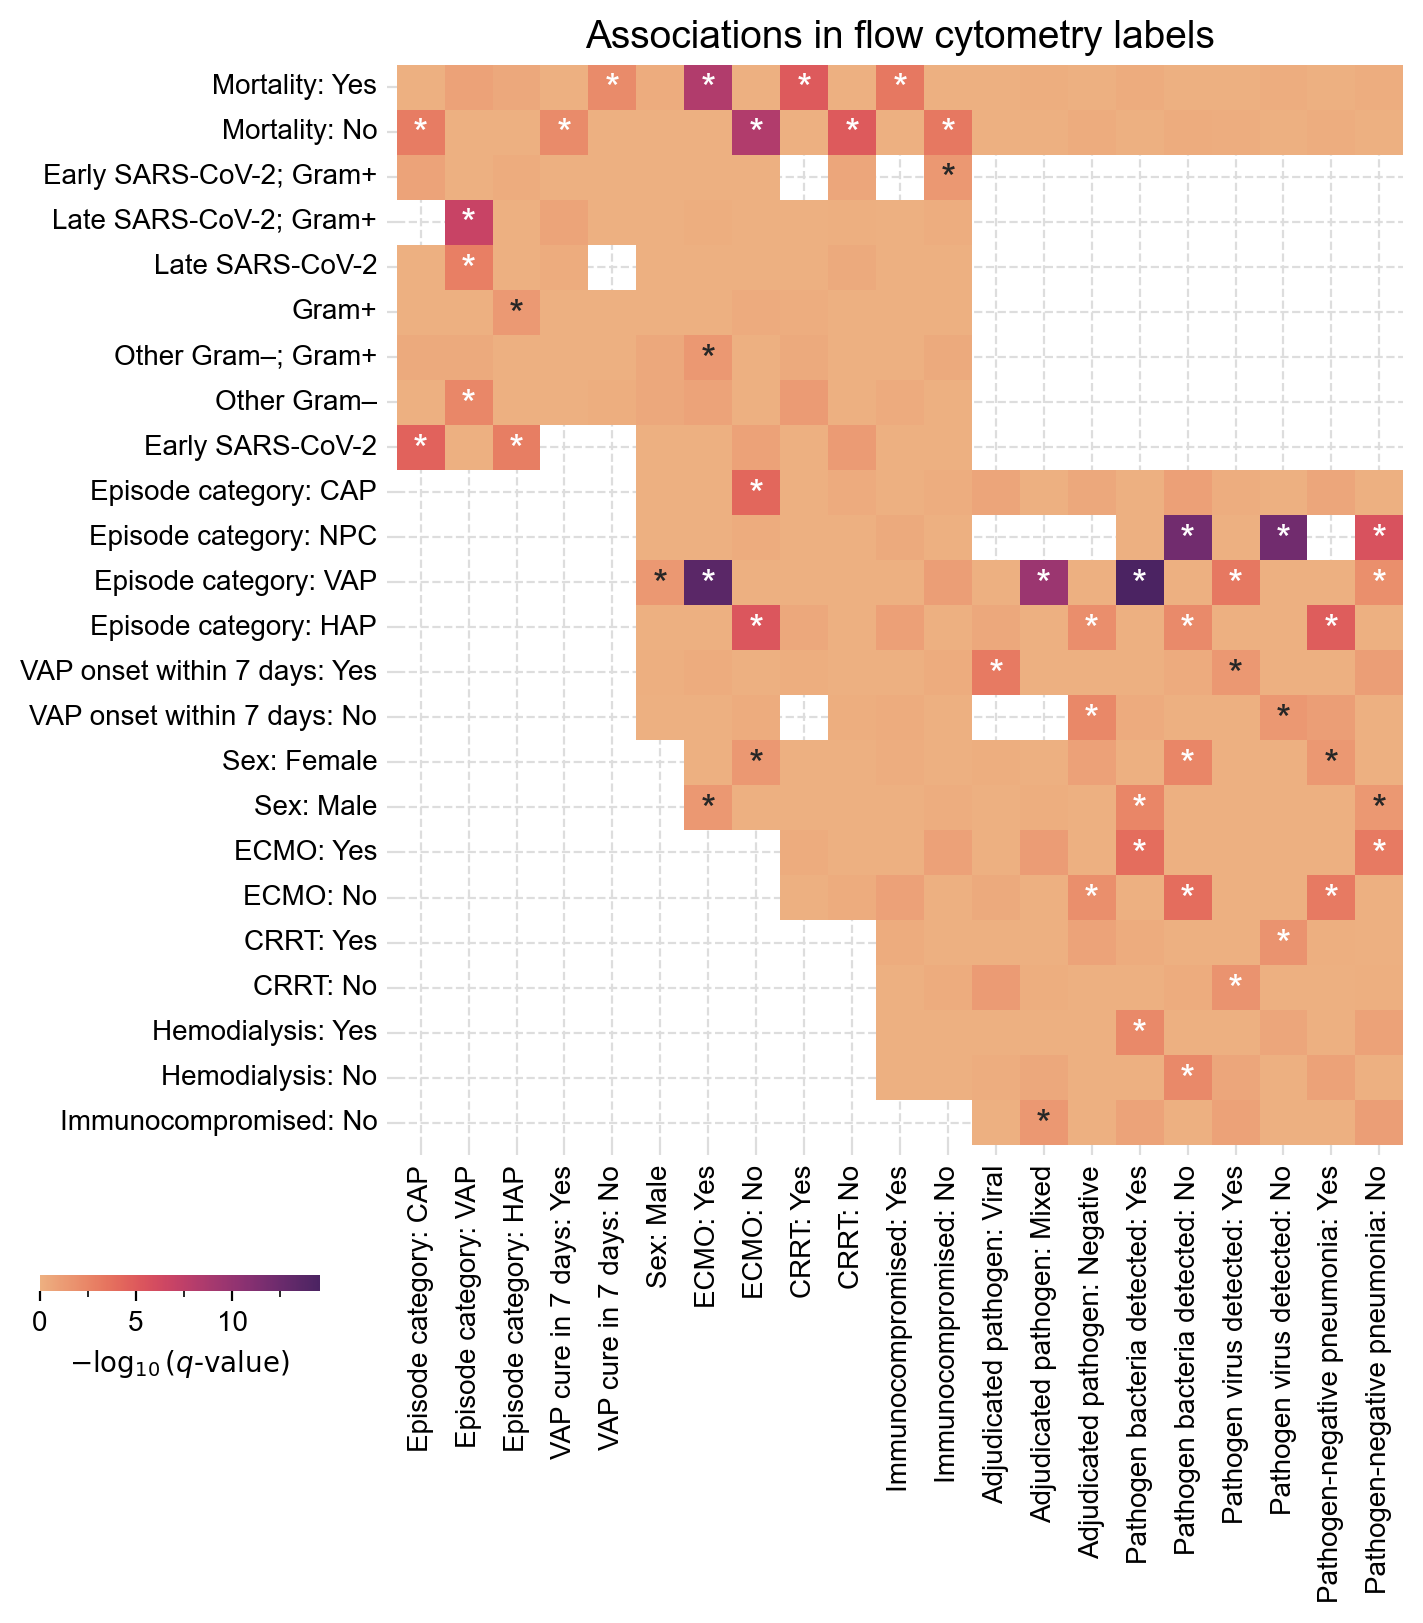

In [40]:
fig, ax = plt.subplots(figsize=(7, 8), constrained_layout=True)
cax = fig.add_axes((0.02, 0.2, 0.2, 0.01))
stars = fdr_result.copy()
stars = stars.applymap(lambda x: np.isnan(x) and '' or x < 0.05 and '*' or '')
signif_row_idx = fdr_result.lt(0.05).sum(axis=1).gt(0).values
signif_col_idx = fdr_result.lt(0.05).sum(axis=0).gt(0).values
log10_result = fdr_result.astype(float).to_numpy()
log10_result[:] = -np.log10(log10_result)
log10_result[np.isnan(log10_result)] = 0
inf_idx = ~np.isfinite(log10_result)
print(inf_idx.sum(), 'associations with exact 0 p-value')
log10_result[inf_idx] = log10_result[~inf_idx].max() + 1
sns.heatmap(
    log10_result[signif_row_idx][:, signif_col_idx],
    mask=fdr_result.isna().to_numpy()[signif_row_idx][:, signif_col_idx],
    yticklabels=[display_label(l) for l in result.index[signif_row_idx]],
    xticklabels=[display_label(l) for l in result.columns[signif_col_idx]],
    annot=stars.loc[signif_row_idx].loc[:, signif_col_idx],
    fmt='s',
    ax=ax,
    cmap='flare',
    cbar_ax=cax,
    cbar_kws=dict(
        orientation='horizontal',
        label=r'$-\log_{10}(q\text{-value})$'
    ),
    annot_kws=dict(
        size=14,
    ),
    zorder=2
)
ax.set_title('Associations in flow cytometry labels', size=14)
ax.grid(color='#ddd', zorder=5, ls='dashed')
ax.tick_params(color='#ddd')
# cax.set_xticks([0, 5, 10, 15])
cax.set_xticks([2.5, 7.5, 12.5], minor=True)
trans = mpl.transforms.Affine2D().translate(0, -4)
for t in ax.texts:
    if t.get_text() == '*':
        t.set_transform(t.get_transform() + trans)
fig.savefig('00_figures/06_corr_structure_flow.pdf')